[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/skoc62_labs.ipynb)


# Data Analysis Labs


- Load [synthetic dataset](https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/skpm20_exam_260213.tsv) and analyze the model below:

[![](https://mermaid.ink/img/pako:eNqVU11v2jAU_SuWUSUqBZbE4SNehVSVPUya9tBKe1hTIRMbsAh2dONQGOK_7wYSIOtemkiJfXzPuefa1weaWqkop0sQ-Yr8eE4MwUdqUKnT1pyQM1aU83PQoxHZvtAFeX2YT74tFhhZEAwVkgjntCulevgyn7ydaR_lGvQ6ursj341UucKPceSXAC3mmSquEXobdHOwskzdLBVOLS3s72-Xw66QWwVutq3IxrUWWdeB0G6mdvjHqAKt3Dd11QamH9Lf-N8Gr1WxdYpWlW__6DxZY87Ftu2TXm9SCbVM_w9kbRBNNRlQ_SeeFnlx-0ybZX0sOFHXM1noLOOdRVy9XuHArhXvpGlaj3tSFCsBIPacDMjgVqLyWLNPz4XNGPNSm1ngHd_325Tw8xT2WYpsjC1BKXMhhPMoGAwbDkrdbNNUwFoBeQSw7812kS72mE5VgbICHPYq8esuweX1yymX7wVeSJoUaKTZt3ct3YqH-e5rYqiH10VLyh2UyqMbBRtRTemhkkuoW6mNSijHoUQjCU3METm5ML-t3TQ0sOVyRflCZAXOylxiW0-1wDu2uaBQtSQ82dI4ylkUnEQoP9Ad5UE87o_G43EcDQeMhT7z6B5RNurHo3g0DgM_iuIwPHr0zymr3x9G0WgY-4NREMUsPP4FnsE59g?type=png)](https://mermaid.live/edit#pako:eNqVU11v2jAU_SuWUSUqBZbE4SNehVSVPUya9tBKe1hTIRMbsAh2dONQGOK_7wYSIOtemkiJfXzPuefa1weaWqkop0sQ-Yr8eE4MwUdqUKnT1pyQM1aU83PQoxHZvtAFeX2YT74tFhhZEAwVkgjntCulevgyn7ydaR_lGvQ6ursj341UucKPceSXAC3mmSquEXobdHOwskzdLBVOLS3s72-Xw66QWwVutq3IxrUWWdeB0G6mdvjHqAKt3Dd11QamH9Lf-N8Gr1WxdYpWlW__6DxZY87Ftu2TXm9SCbVM_w9kbRBNNRlQ_SeeFnlx-0ybZX0sOFHXM1noLOOdRVy9XuHArhXvpGlaj3tSFCsBIPacDMjgVqLyWLNPz4XNGPNSm1ngHd_325Tw8xT2WYpsjC1BKXMhhPMoGAwbDkrdbNNUwFoBeQSw7812kS72mE5VgbICHPYq8esuweX1yymX7wVeSJoUaKTZt3ct3YqH-e5rYqiH10VLyh2UyqMbBRtRTemhkkuoW6mNSijHoUQjCU3METm5ML-t3TQ0sOVyRflCZAXOylxiW0-1wDu2uaBQtSQ82dI4ylkUnEQoP9Ad5UE87o_G43EcDQeMhT7z6B5RNurHo3g0DgM_iuIwPHr0zymr3x9G0WgY-4NREMUsPP4FnsE59g)

- Perform descriptive statistics and data transformations
- Perform bivariate analyses and hypothesis testing
- Perform multivariate analysis, multiple regression


## loading dataset

This code initializes a data science environment by importing **NumPy**, **Pandas**, **Matplotlib**, and **SciPy** for comprehensive analysis. It retrieves the "Palmer Penguins" dataset from a remote GitHub URL, specifically using the `sep="\t"` parameter to correctly parse the **Tab-Separated Values** (TSV) format. The script concludes by calling `df.shape`, which verifies the dataset's dimensions by displaying the total count of rows and columns.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load the dataset
path = "https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/skoc62_labs.tsv"
df = pd.read_csv(path, sep="\t")

print(df.shape)

(500, 9)


This command displays the **structure** of the DataFrame by default. It is used to quickly inspect the data structure, verify that the column headers align with the values, and get a "sneak peek" at the formatting and data types within the set. Use the output to prompt [Google Gemini](https://gemini.google.com) to initialize your data analysis, e.g. **prompt:** "im analyzing a dataframe called df with the following structure, generate code to perform ..."

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   participant_id           500 non-null    object 
 1   advert_variant           500 non-null    object 
 2   product_category         483 non-null    object 
 3   trait_openness           469 non-null    float64
 4   trait_conscientiousness  484 non-null    float64
 5   trait_extraversion       473 non-null    float64
 6   trait_agreeableness      469 non-null    float64
 7   trait_neuroticism        475 non-null    float64
 8   advert_attitude          472 non-null    float64
dtypes: float64(6), object(3)
memory usage: 35.3+ KB


# 1. Descriptive statistics


## use subheadings

Add new text cells like this to write a few sentences explaining the analysis in the associated code cell. Feel free to add subheadings, but don't change the main sections of the notebook. Make note of and explain the findings of your analysis. Visualize your data!

Descriptive Statistics for Advert Attitude:
count    472.000000
mean      13.946819
std        2.058864
min        1.776106
25%       12.890047
50%       13.748285
75%       14.851972
max       29.365980
Name: advert_attitude, dtype: float64


<Figure size 640x480 with 0 Axes>

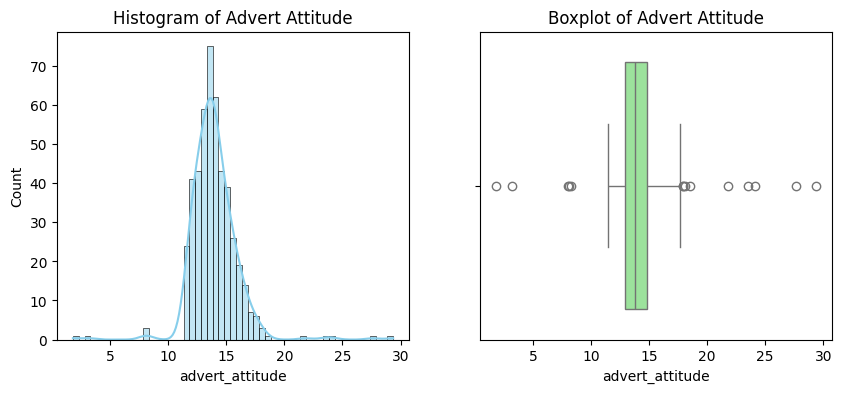

In [ ]:
# code cell 1.1, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive Statistics
print("Descriptive Statistics for Advert Attitude:")
print(df['advert_attitude'].describe())

# Visualization: Histogram and Boxplot
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['advert_attitude'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Advert Attitude')
sns.boxplot(x=df['advert_attitude'].dropna(), ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Advert Attitude')
plt.savefig('advert_attitude_analysis.png')

Frequency Table for Product Category:
product_category
social_events          103
travel_experiential    101
accessories_tech        96
productivity_apps       94
luxury_fashion          89
NaN                     17
Name: count, dtype: int64


/tmp/ipykernel_193/1044736077.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='product_category', order=order_pc, palette='viridis')


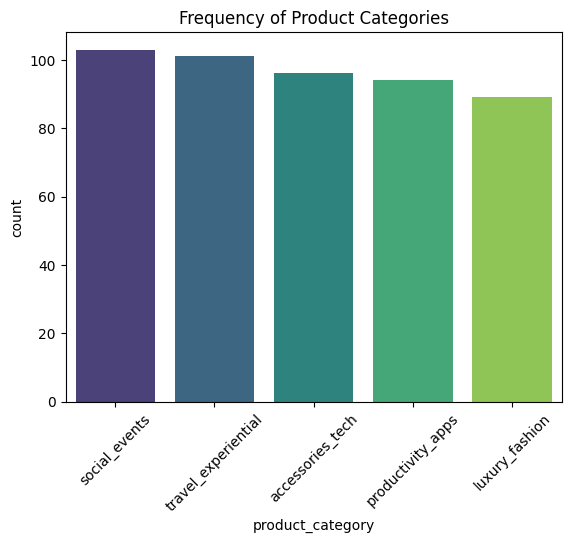

In [ ]:
# code cell 1.2, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Frequency Table (including missing values)
print("Frequency Table for Product Category:")
print(df['product_category'].value_counts(dropna=False))

# Visualization: Frequency Bar Chart
plt.clf()
# Sorting categories by frequency for better readability
order_pc = df['product_category'].value_counts().index
sns.countplot(data=df, x='product_category', order=order_pc, palette='viridis')
plt.title('Frequency of Product Categories')
plt.xticks(rotation=45)
plt.savefig('product_category_analysis.png')

Frequency Table for Advert Variant:
advert_variant
treatment    250
control      250
Name: count, dtype: int64


/tmp/ipykernel_193/2951646371.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='advert_variant', order=order_av, palette='magma')


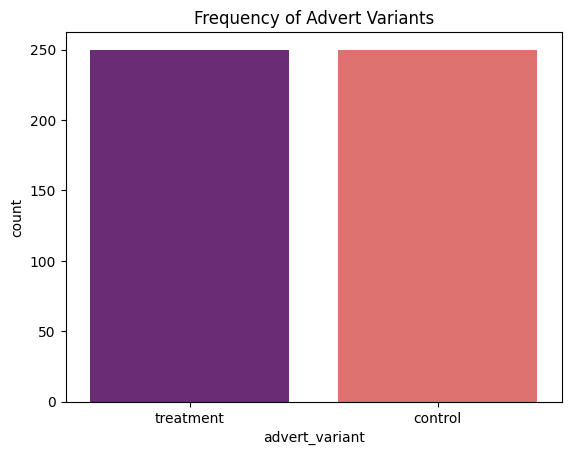

In [ ]:
# code cell 1.3, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Frequency Table
print("Frequency Table for Advert Variant:")
print(df['advert_variant'].value_counts())

# Visualization: Frequency Bar Chart
plt.clf()
order_av = df['advert_variant'].value_counts().index
sns.countplot(data=df, x='advert_variant', order=order_av, palette='magma')
plt.title('Frequency of Advert Variants')
plt.savefig('advert_variant_analysis.png')

Descriptive Statistics for Trait Extraversion:
count    473.000000
mean       3.487451
std        0.356879
min        2.333333
25%        3.291667
50%        3.520833
75%        3.708333
max        4.416667
Name: trait_extraversion, dtype: float64


<Figure size 640x480 with 0 Axes>

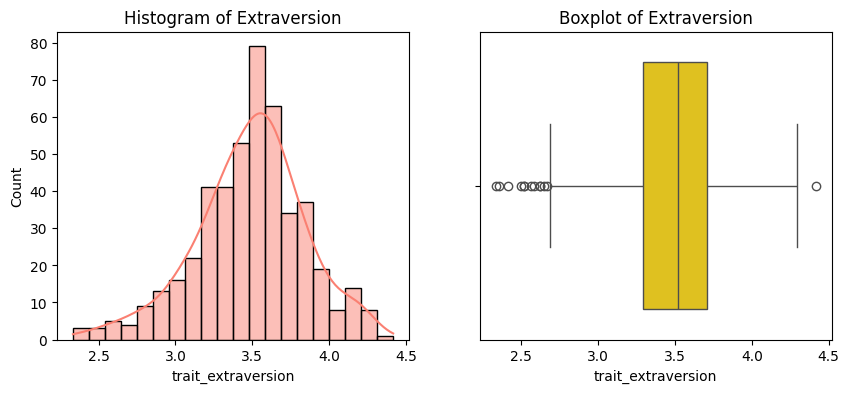

In [ ]:
# code cell 1.4, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive Statistics
print("Descriptive Statistics for Trait Extraversion:")
print(df['trait_extraversion'].describe())

# Visualization: Histogram and Boxplot
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['trait_extraversion'].dropna(), kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Histogram of Extraversion')
sns.boxplot(x=df['trait_extraversion'].dropna(), ax=axes[1], color='gold')
axes[1].set_title('Boxplot of Extraversion')
plt.savefig('trait_extraversion_analysis.png')

# 2. Data transformations

Total outliers detected: 14
Outlier Details (Prior to Inplace Replacement):
    participant_id  advert_attitude
20           dwsh5        18.062925
72           53z3c        23.505383
100          hy34s         8.238036
107          t34jr        24.138574
132          1b1ym         8.094133
169          atpgb         7.966995
188          flht8        18.482416
252          y6zpl         1.776106
284          psvq3        27.618558
294          3x8gd         3.188141
349          kaav5        29.365980
370          mrxlo        21.790839
439          4tqi4        17.880320
488          stw2l        17.909211

Outliers replaced with median value: 13.7483
Descriptive Statistics for Advert Attitude:
count    472.000000
mean      13.871519
std        1.365179
min       11.454328
25%       12.911710
50%       13.748285
75%       14.688075
max       17.674593
Name: advert_attitude, dtype: float64


<Figure size 640x480 with 0 Axes>

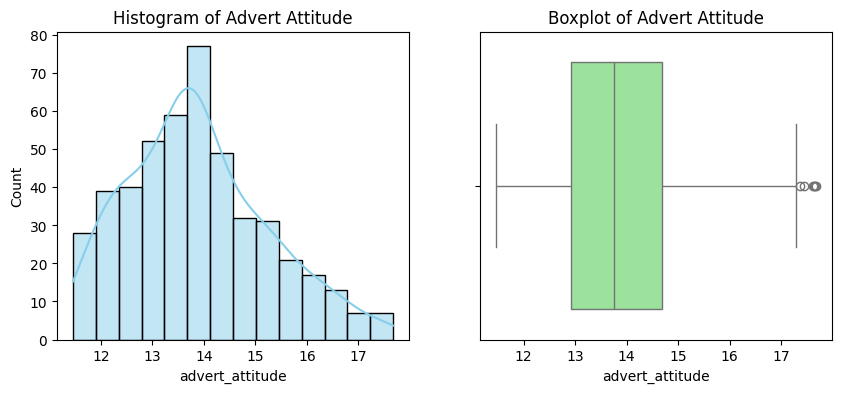

In [ ]:
# code cell 2.1, keep this comment, edit content but do not add more code cells
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate IQR and boundaries
# IQR is used to define the range of "normal" values
Q1 = df['advert_attitude'].quantile(0.25)
Q3 = df['advert_attitude'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Identify outliers
# Boolean mask for values outside the [lower_bound, upper_bound] range
outlier_mask = (df['advert_attitude'] < lower_bound) | (df['advert_attitude'] > upper_bound)

# --- Print row number and participant_id for outliers before replacement ---
print(f"Total outliers detected: {outlier_mask.sum()}")
if outlier_mask.any():
    print("Outlier Details (Prior to Inplace Replacement):")
    # Displays the row index and participant_id for identification
    print(df.loc[outlier_mask, ['participant_id', 'advert_attitude']])
else:
    print("No outliers found.")
# ---------------------------------------------------------------------------

# 3. Replace outliers with the median value INPLACE
# This modifies the original 'advert_attitude' column directly
median_val = df['advert_attitude'].median()
df.loc[outlier_mask, 'advert_attitude'] = median_val

print(f"\nOutliers replaced with median value: {median_val:.4f}")

# 4. Visualize the updated original variable with a boxplot
# Descriptive Statistics
print("Descriptive Statistics for Advert Attitude:")
print(df['advert_attitude'].describe())

# Visualization: Histogram and Boxplot
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['advert_attitude'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Advert Attitude')
sns.boxplot(x=df['advert_attitude'].dropna(), ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Advert Attitude')
plt.savefig('advert_attitude_analysis_normalized.png')

In [ ]:
# code cell 2.2, keep this comment, edit content but do not add more code cells
import pandas as pd

# 1. Identify missing values
missing_mask = df['product_category'].isna()
num_missing = missing_mask.sum()

# 2. Print row information for missing values
print(f"Number of missing values in 'product_category': {num_missing}")
if num_missing > 0:
    print("Rows with missing 'product_category':")
    print(df.loc[missing_mask, ['participant_id', 'product_category']])

# 3. Calculate the mode value
# We select the first element [0] in case there is a tie
mode_val = df['product_category'].mode()[0]
print(f"\nMode value identified: {mode_val}")

# 4. Replace missing values using direct assignment (avoids FutureWarning)
# This is the modern, recommended way to perform the operation "inplace"
df['product_category'] = df['product_category'].fillna(mode_val)

print("\nMissing values successfully replaced via direct assignment.")

Number of missing values in 'product_category': 17
Rows with missing 'product_category':
    participant_id product_category
26           pc23b              NaN
29           x7zhv              NaN
42           j13ur              NaN
51           jj3ov              NaN
135          p1lh2              NaN
149          twns1              NaN
162          kn9nh              NaN
186          rp9ds              NaN
187          a79oq              NaN
205          bujkl              NaN
223          p3daa              NaN
230          htg93              NaN
238          hmgom              NaN
286          c3j7e              NaN
331          mlc91              NaN
337          rg9vq              NaN
363          j3pzm              NaN

Mode value identified: social_events

Missing values successfully replaced via direct assignment.


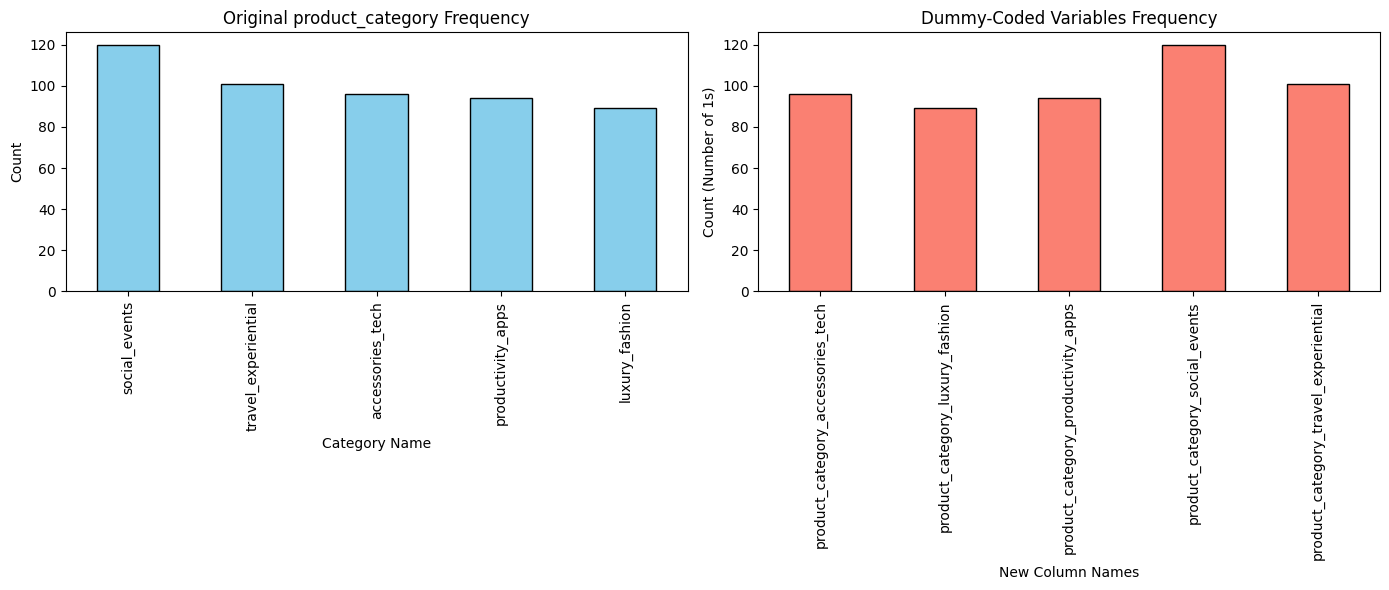

Updated DataFrame with Dummy Columns:
    product_category  product_category_accessories_tech  \
0   accessories_tech                               True   
1      social_events                              False   
2  productivity_apps                              False   
3  productivity_apps                              False   
4  productivity_apps                              False   

   product_category_luxury_fashion  product_category_productivity_apps  \
0                            False                               False   
1                            False                               False   
2                            False                                True   
3                            False                                True   
4                            False                                True   

   product_category_social_events  product_category_travel_experiential  
0                           False                                 False  
1             

In [ ]:
# code cell 2.3, keep this comment, edit content but do not add more code cells
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate Dummy Variables
# prefix_sep='_' will result in columns like product_category_Electronics
df_dummies = pd.get_dummies(df['product_category'], prefix='product_category')

# Add the new dummy columns back to our main dataframe
df = pd.concat([df, df_dummies], axis=1)

# 2. Prepare Data for Visualization
# Get frequency counts for the original categorical variable
original_counts = df['product_category'].value_counts()

# Get frequency counts for the new dummy variables (summing the 1s)
dummy_cols = df_dummies.columns
dummy_counts = df[dummy_cols].sum()

# 3. Create Side-by-Side Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Original Variable Frequency
original_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Original product_category Frequency')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Category Name')

# Plot 2: New Dummy Variables Frequency
dummy_counts.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Dummy-Coded Variables Frequency')
axes[1].set_ylabel('Count (Number of 1s)')
axes[1].set_xlabel('New Column Names')

plt.tight_layout()
plt.show()

# Print the first few rows to verify the transformation
print("Updated DataFrame with Dummy Columns:")
print(df[['product_category'] + list(dummy_cols)].head())

In [ ]:
# code cell 2.4, keep this comment, edit content but do not add more code cells


# 3. Bivariate analysis


--- Mean Advert Attitude by Variant ---
  advert_variant  advert_attitude
0      treatment        14.193134
1        control        13.557979


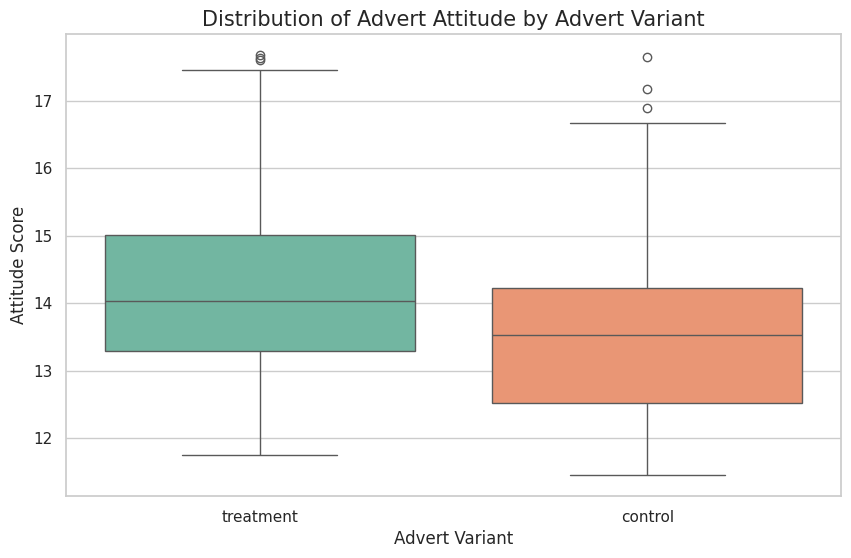

In [ ]:
# code cell 3.1, keep this comment, edit content but do not add more code cells
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate numerical means grouped by the advert variant
# We sort them to make the visualization easier to interpret
variant_means = df.groupby('advert_variant', observed=True)['advert_attitude'].mean().sort_values(ascending=False).reset_index()

print("--- Mean Advert Attitude by Variant ---")
print(variant_means)

# Set the visual style
sns.set_theme(style="whitegrid")

# 2. Visualization: Boxplot for Distribution and Outliers
# Fixed the Futurewarning by assigning x to hue and setting legend=False
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='advert_variant',
    y='advert_attitude',
    hue='advert_variant',
    palette='Set2',
    legend=False
)
plt.title('Distribution of Advert Attitude by Advert Variant', fontsize=15)
plt.xlabel('Advert Variant', fontsize=12)
plt.ylabel('Attitude Score', fontsize=12)
plt.show()

--- Mean Advert Attitude by Product Category ---
      product_category  advert_attitude
0  travel_experiential        14.853974
1        social_events        14.025968
2     accessories_tech        13.983948
3       luxury_fashion        13.403160
4    productivity_apps        12.963458


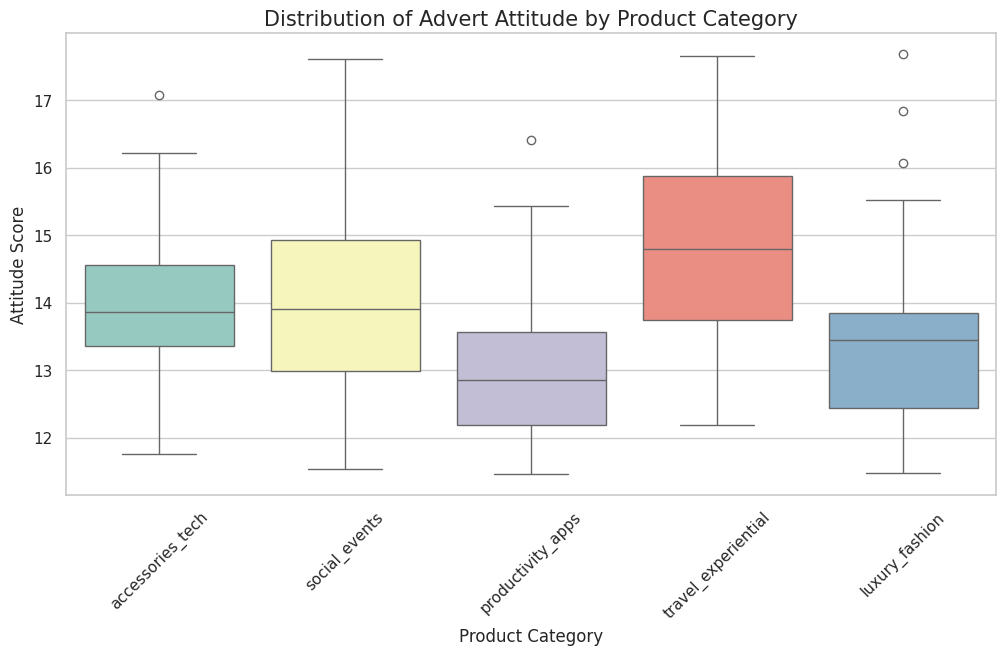

In [ ]:
# code cell 3.2, keep this comment, edit content but do not add more code cells
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate numerical means grouped by the product category
# Sorting helps identify which category responds best to advertising
category_means = df.groupby('product_category', observed=True)['advert_attitude'].mean().sort_values(ascending=False).reset_index()

print("--- Mean Advert Attitude by Product Category ---")
print(category_means)

# Set the visual style
sns.set_theme(style="whitegrid")

# 2. Visualization: Boxplot for Distribution by Category
# Using hue and legend=False to prevent the previous FutureWarning
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='product_category',
    y='advert_attitude',
    hue='product_category',
    palette='Set3',
    legend=False
)

plt.title('Distribution of Advert Attitude by Product Category', fontsize=15)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Attitude Score', fontsize=12)
plt.xticks(rotation=45) # Rotated labels in case category names are long
plt.show()

--- Bivariate Analysis: Extraversion vs. Attitude ---
Pearson Correlation Coefficient: 0.280

--- Summary Statistics ---
       trait_extraversion  advert_attitude
count          473.000000       472.000000
mean             3.487451        13.871519
std              0.356879         1.365179
min              2.333333        11.454328
25%              3.291667        12.911710
50%              3.520833        13.748285
75%              3.708333        14.688075
max              4.416667        17.674593


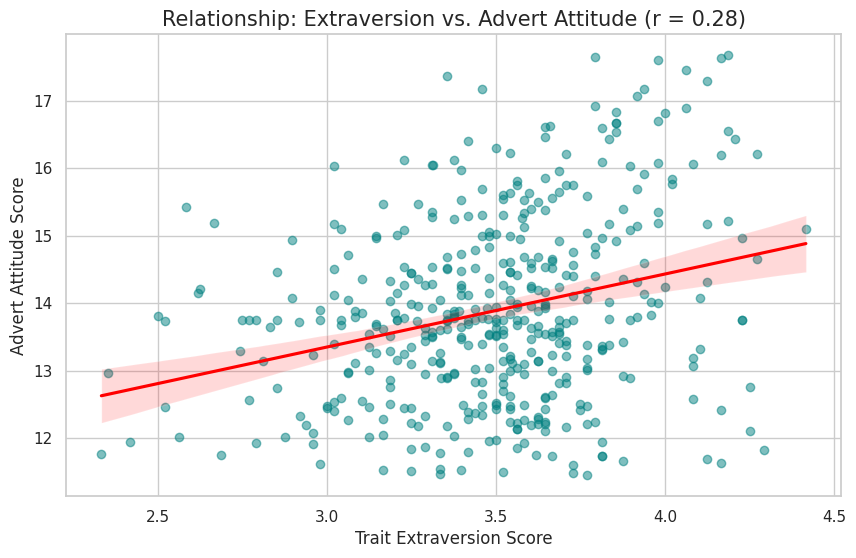

In [ ]:
# code cell 3.3, keep this comment, edit content but do not add more code cells
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Numerical Descriptives: Correlation Coefficient
# This measures the strength and direction of the linear relationship
correlation = df['trait_extraversion'].corr(df['advert_attitude'])
print(f"--- Bivariate Analysis: Extraversion vs. Attitude ---")
print(f"Pearson Correlation Coefficient: {correlation:.3f}")

# Descriptive stats for both variables
print("\n--- Summary Statistics ---")
print(df[['trait_extraversion', 'advert_attitude']].describe())

# Set the visual style
sns.set_theme(style="whitegrid")

# 2. Visualization: Scatter Plot with Regression Line
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='trait_extraversion',
    y='advert_attitude',
    scatter_kws={'alpha':0.5, 'color':'teal'},
    line_kws={'color':'red'}
)

plt.title(f'Relationship: Extraversion vs. Advert Attitude (r = {correlation:.2f})', fontsize=15)
plt.xlabel('Trait Extraversion Score', fontsize=12)
plt.ylabel('Advert Attitude Score', fontsize=12)
plt.show()

In [ ]:
# code cell 3.4, keep this comment, edit content but do not add more code cells


# 4. Hypothesis testing


In [ ]:
# code cell 4.1, keep this comment, edit content but do not add more code cells
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Prepare the data
# Dropping rows with missing values in either column for the statistical test
clean_data = df.dropna(subset=['advert_variant', 'advert_attitude'])

# Identify the two categories
variants = clean_data['advert_variant'].unique()

if len(variants) != 2:
    print(f"Error: Expected 2 categories, but found {len(variants)}: {variants}")
else:
    # --- NEW: Print Group Means and Descriptives ---
    group_stats = clean_data.groupby('advert_variant')['advert_attitude'].agg(['mean', 'std', 'count'])
    print("--- Group Statistics ---")
    print(group_stats)
    print("\n")

    group1 = clean_data[clean_data['advert_variant'] == variants[0]]['advert_attitude']
    group2 = clean_data[clean_data['advert_variant'] == variants[1]]['advert_attitude']

    # 2. Check for Homogeneity of Variances (Levene's Test)
    stat_lev, p_lev = stats.levene(group1, group2)
    equal_var_assumption = p_lev > 0.05

    # 3. Perform Independent Samples T-test
    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=equal_var_assumption)

    # 4. Numerical Descriptives
    print(f"--- Statistical Test: {variants[0]} vs {variants[1]} ---")
    print(f"Levene's Test for Equal Variances: p = {p_lev:.4f} (Equal variances assumed: {equal_var_assumption})")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_val:.4f}")

    # Interpretation
    alpha = 0.05
    if p_val < alpha:
        print("\nResult: Significant difference found between the two variants.")
    else:
        print("\nResult: No significant difference found between the two variants.")

--- Group Statistics ---
                     mean       std  count
advert_variant                            
control         13.557979  1.310922    239
treatment       14.193134  1.347421    233


--- Statistical Test: treatment vs control ---
Levene's Test for Equal Variances: p = 0.5721 (Equal variances assumed: True)
T-statistic: 5.1909
P-value: 0.0000

Result: Significant difference found between the two variants.


In [ ]:
# code cell 4.2, keep this comment, edit content but do not add more code cells
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Data Preparation
# Dropping missing values in the variables of interest for accurate testing
df_clean = df.dropna(subset=['product_category', 'advert_attitude'])

# --- Group Statistics ---
# Calculating means and standard deviations for context
group_stats = df_clean.groupby('product_category')['advert_attitude'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
print("--- Group Means and Statistics ---")
print(group_stats)
print("\n")

# 2. Check for Homogeneity of Variances (Levene's Test)
# This test checks if the variance is equal across all categories
groups = [group['advert_attitude'].values for name, group in df_clean.groupby('product_category')]
stat_lev, p_lev = stats.levene(*groups)

print("--- Homogeneity of Variances ---")
print(f"Levene's Test: p-value = {p_lev:.4f}")
if p_lev < 0.05:
    print("Warning: Variances are not equal across groups. ANOVA results should be interpreted with caution.")

# 3. One-Way ANOVA
# We use a linear model to perform the ANOVA
model = ols('advert_attitude ~ C(product_category)', data=df_clean).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n--- One-Way ANOVA Results ---")
print(anova_table)

# 4. Post-Hoc Analysis (Tukey's HSD)
# If the ANOVA p-value is significant (< 0.05), we look for specific group differences
p_anova = anova_table['PR(>F)'][0]

if p_anova < 0.05:
    print("\nResult: Significant difference found between categories. Performing Tukey HSD...")
    tukey = pairwise_tukeyhsd(endog=df_clean['advert_attitude'],
                              groups=df_clean['product_category'],
                              alpha=0.05)
    print(tukey)
else:
    print("\nResult: No significant difference found between the product categories (p >= 0.05).")

--- Group Means and Statistics ---
                          mean       std  count
product_category                               
travel_experiential  14.853974  1.309375     96
social_events        14.025968  1.422921    110
accessories_tech     13.983948  1.002455     91
luxury_fashion       13.403160  1.174615     85
productivity_apps    12.963458  1.052613     90


--- Homogeneity of Variances ---
Levene's Test: p-value = 0.0026

--- One-Way ANOVA Results ---
                         sum_sq     df          F        PR(>F)
C(product_category)  189.292625    4.0  32.097854  1.201302e-23
Residual             688.516859  467.0        NaN           NaN

Result: Significant difference found between categories. Performing Tukey HSD...


/tmp/ipykernel_193/1989925485.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_anova = anova_table['PR(>F)'][0]


            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
 accessories_tech      luxury_fashion  -0.5808 0.0139 -1.0824 -0.0792   True
 accessories_tech   productivity_apps  -1.0205    0.0 -1.5148 -0.5262   True
 accessories_tech       social_events    0.042 0.9992 -0.4292  0.5132  False
 accessories_tech travel_experiential     0.87    0.0  0.3835  1.3565   True
   luxury_fashion   productivity_apps  -0.4397 0.1186 -0.9426  0.0632  False
   luxury_fashion       social_events   0.6228 0.0038  0.1426   1.103   True
   luxury_fashion travel_experiential   1.4508    0.0  0.9556   1.946   True
productivity_apps       social_events   1.0625    0.0  0.5899  1.5351   True
productivity_apps travel_experiential   1.8905    0.0  1.4026  2.3784   True
    social_events travel_experiential    0.828    0.0  0.3636  1.2924   True

In [ ]:
# code cell 4.3, keep this comment, edit content but do not add more code cells
import pandas as pd
from scipy import stats

# 1. Data Preparation
# Dropping rows with missing values in either variable for an accurate correlation test
df_clean = df.dropna(subset=['trait_extraversion', 'advert_attitude'])

# 2. Descriptive Statistics
print("--- Summary Statistics ---")
print(df_clean[['trait_extraversion', 'advert_attitude']].describe())
print("\n")

# 3. Pearson Correlation Test
# This returns the correlation coefficient (r) and the p-value
r_coeff, p_value = stats.pearsonr(df_clean['trait_extraversion'], df_clean['advert_attitude'])

print(f"--- Statistical Test: Extraversion vs. Advert Attitude ---")
print(f"Pearson Correlation Coefficient (r): {r_coeff:.4f}")
print(f"P-value: {p_value:.4f}")

# 4. Interpretation
alpha = 0.05
if p_value < alpha:
    if r_coeff > 0:
        direction = "positive"
    else:
        direction = "negative"
    print(f"\nResult: There is a statistically significant {direction} linear relationship.")
else:
    print("\nResult: No statistically significant linear relationship was found (p >= 0.05).")

--- Summary Statistics ---
       trait_extraversion  advert_attitude
count          447.000000       447.000000
mean             3.493594        13.886779
std              0.355639         1.371820
min              2.333333        11.454328
25%              3.291667        12.909071
50%              3.520833        13.748285
75%              3.708333        14.689192
max              4.416667        17.674593


--- Statistical Test: Extraversion vs. Advert Attitude ---
Pearson Correlation Coefficient (r): 0.2805
P-value: 0.0000

Result: There is a statistically significant positive linear relationship.


In [ ]:
# code cell 4.4, keep this comment, edit content but do not add more code cells
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   participant_id                        500 non-null    object 
 1   advert_variant                        500 non-null    object 
 2   product_category                      500 non-null    object 
 3   trait_openness                        469 non-null    float64
 4   trait_conscientiousness               484 non-null    float64
 5   trait_extraversion                    473 non-null    float64
 6   trait_agreeableness                   469 non-null    float64
 7   trait_neuroticism                     475 non-null    float64
 8   advert_attitude                       472 non-null    float64
 9   product_category_accessories_tech     500 non-null    bool   
 10  product_category_luxury_fashion       500 non-null    bool   
 11  product_category_pr

# 5. Multivariate analysis


In [ ]:
# code cell 5.1, keep this comment, edit content but do not add more code cells
import pandas as pd
import statsmodels.api as sm

# 1. Prepare the Data
# Use .copy() to avoid the SettingWithCopyWarning
df_reg = df.dropna(subset=['advert_attitude', 'trait_extraversion']).copy()

# 2. Encode binary advert_variant
# We ensure it's an integer to avoid 'object' dtype issues
df_reg['variant_binary'] = pd.get_dummies(df_reg['advert_variant'], drop_first=True).astype(int)

# 3. Define Independent Variables (X)
# We cast the boolean category columns to int(0/1) to fix the ValueError
category_cols = [
    'product_category_accessories_tech',
    'product_category_luxury_fashion',
    'product_category_productivity_apps',
    'product_category_social_events'
]

# Select and cast all features to float/int
X = df_reg[['trait_extraversion', 'variant_binary'] + category_cols].astype(float)

# Adding the intercept constant
X = sm.add_constant(X)
y = df_reg['advert_attitude'].astype(float)

# 4. Fit the Model
model = sm.OLS(y, X).fit()

# 5. Output Descriptives and Results
print("--- Descriptive Statistics ---")
print(df_reg[['advert_attitude', 'trait_extraversion']].describe())

print("\n--- Multiple Regression Model Summary ---")
print(model.summary())

# Explanation of Reference Group
print("\nNOTE: 'product_category_travel_experiential' is the reference category.")

--- Descriptive Statistics ---
       advert_attitude  trait_extraversion
count       447.000000          447.000000
mean         13.886779            3.493594
std           1.371820            0.355639
min          11.454328            2.333333
25%          12.909071            3.291667
50%          13.748285            3.520833
75%          14.689192            3.708333
max          17.674593            4.416667

--- Multiple Regression Model Summary ---
                            OLS Regression Results                            
Dep. Variable:        advert_attitude   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     35.07
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           1.18e-34
Time:                        09:53:18   Log-Likelihood:                -687.72
No. Observations:                 447   AIC:                     

This regression model explains approximately **32.4% of the variance** in advertisement attitudes ($R^2 = 0.324$), with all included predictors reaching high statistical significance ($p < 0.001$). **Trait extraversion** is a strong positive driver; for every one-unit increase in extraversion, ad attitude improves by roughly **1.01 points**. Similarly, switching to the alternative **advert variant** (indicated by `variant_binary`) yields a significant boost of **0.54 points**. Interestingly, all specific product categories show negative coefficients compared to the **Travel/Experiential** reference group, with **Productivity Apps** showing the largest relative deficit ($-1.80$). This suggests that, while extraversion and the specific ad variant improve engagement, the "Travel/Experiential" category remains the most inherently effective context for these advertisements.

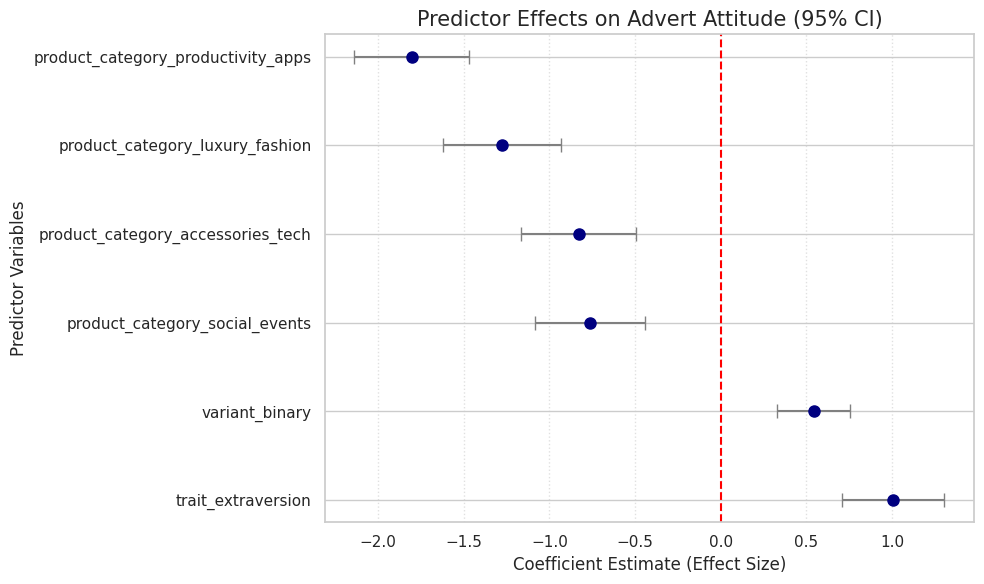

In [ ]:
# code cell 5.2, keep this comment, edit content but do not add more code cells
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract coefficients and confidence intervals from the model
# We exclude the 'const' (intercept) to focus on the relative impact of predictors
coef_df = model.params.drop('const').reset_index()
coef_df.columns = ['predictor', 'coefficient']

# Get 95% Confidence Intervals
conf_int = model.conf_int().drop('const')
coef_df['error_minus'] = coef_df['coefficient'] - conf_int[0].values
coef_df['error_plus'] = conf_int[1].values - coef_df['coefficient']

# 2. Sort for better readability
coef_df = coef_df.sort_values(by='coefficient', ascending=False)

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Plot the points and error bars
plt.errorbar(x=coef_df['coefficient'], y=coef_df['predictor'],
             xerr=[coef_df['error_minus'], coef_df['error_plus']],
             fmt='o', color='navy', ecolor='gray', capsize=5, markersize=8)

# Add a vertical baseline at 0
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)

# 4. Customize labels and title
plt.title('Predictor Effects on Advert Attitude (95% CI)', fontsize=15)
plt.xlabel('Coefficient Estimate (Effect Size)', fontsize=12)
plt.ylabel('Predictor Variables', fontsize=12)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# code cell 5.3, keep this comment, edit content but do not add more code cells
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Prepare the same feature matrix (X) used in your model
# We must include the constant, as VIF is calculated based on the full design matrix
X_vif = X.copy()

# 2. Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("--- Multicollinearity Diagnostics (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False))

# 3. Interpretation Helper
high_vif = vif_data[vif_data["VIF"] > 5]
if not high_vif.empty:
    print("\nWarning: High VIF detected in the following variables:")
    print(high_vif)
else:
    print("\nResult: No significant multicollinearity detected (all VIFs < 5).")

--- Multicollinearity Diagnostics (VIF) ---
                              feature         VIF
0                               const  104.912529
6      product_category_social_events    1.649893
5  product_category_productivity_apps    1.593867
3   product_category_accessories_tech    1.572190
4     product_category_luxury_fashion    1.546729
2                      variant_binary    1.011600
1                  trait_extraversion    1.003201

  feature         VIF
0   const  104.912529


The multicollinearity diagnostics indicate that your model is **statistically robust** and free from problematic overlap between predictors. All independent variables, including **trait_extraversion**, **variant_binary**, and the **product_category** dummies, show VIF values between 1.00 and 1.65, which are well below the conservative threshold of 5.0; this confirms that each variable's unique contribution to `advert_attitude` is being measured independently without distortion. While the **constant (intercept)** shows a high VIF of 104.9, this is a common mathematical artifact in models with multiple dummy variables and non-centered continuous data and can be safely ignored. Consequently, you can have high confidence that the coefficients and $p$-values previously calculated are reliable reflections of how personality and category context drive consumer attitudes.

<Figure size 800x600 with 0 Axes>

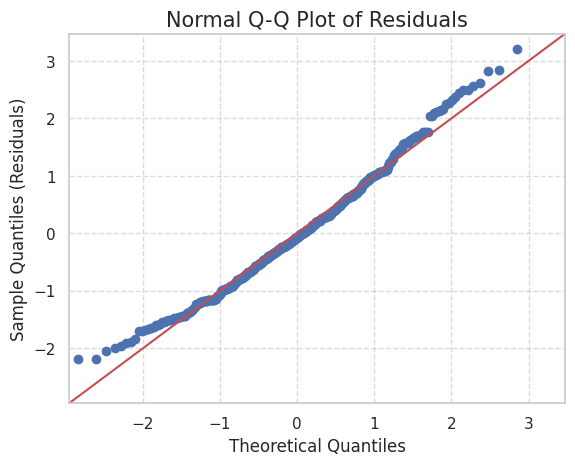

--- Normality Test (Shapiro-Wilk) ---
W-statistic: 0.9866
P-value: 0.0004

Result: Residuals are NOT normally distributed (p < 0.05).


In [ ]:
# code cell 5.4, keep this comment, edit content but do not add more code cells
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Extract the residuals from your fitted model
residuals = model.resid

# 2. Create the Q-Q Plot
plt.figure(figsize=(8, 6))
fig = sm.qqplot(residuals, line='45', fit=True)

# 3. Customize the plot
plt.title('Normal Q-Q Plot of Residuals', fontsize=15)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Sample Quantiles (Residuals)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Display the plot
plt.show()

# Optional: Run a formal normality test (Shapiro-Wilk)
shapiro_test = stats.shapiro(residuals)
print(f"--- Normality Test (Shapiro-Wilk) ---")
print(f"W-statistic: {shapiro_test.statistic:.4f}")
print(f"P-value: {shapiro_test.pvalue:.4f}")

if shapiro_test.pvalue < 0.05:
    print("\nResult: Residuals are NOT normally distributed (p < 0.05).")
else:
    print("\nResult: Residuals appear to be normally distributed (p >= 0.05).")

The Shapiro-Wilk test result ($W = 0.9866, p < 0.001$) indicates that the model's residuals deviate significantly from a normal distribution, confirming that the error terms are not perfectly symmetrical. While a sample size of $N=447$ typically allows the Central Limit Theorem to protect the validity of your coefficient estimates and $p$-values, the non-normality suggests that the model may be struggling to capture extreme values or that the relationship between personality and ad attitude is not strictly linear. This often manifests as "heavy tails" in a Q-Q plot, where the model consistently over- or under-predicts the attitudes of participants with very high or very low engagement scores.